# Stages Demo

This demo walks through the stage-based experiment building pipeline:
1. Setup: gate set and fidelity model
2. Experiment class overview
3. Vanilla pipeline (step by step)
4. Non-vanilla pipeline
5. Experiment composition
6. Individual stage highlights

In [ ]:
from qiskit_ibm_runtime import Executor, QiskitRuntimeService

runtime = QiskitRuntimeService(name="foo")
backend = runtime.backend("ibm_marrakesh")
executor = Executor(backend)

## 1. Build a gate set with a single layer on a ring of qubits

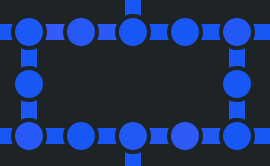

In [ ]:
from qiskit_noise_learning.gate_sets import QiskitGateSet

qubit_subset = [*range(25, 29)]
gate_set = QiskitGateSet(backend.num_qubits, target=backend.target, qubit_subset=qubit_subset)

layer_1_pairs = [(25, 26), (27, 28)]

with gate_set.build_new_gate("L0") as builder:
    for pair in layer_1_pairs:
        builder.circuit.cz(*pair)

In [ ]:
gate_set.draw()

## 2. Create a 2-local Pauli-Lindblad model.

In [ ]:
from qiskit_noise_learning.models import PauliLindbladModel

pauli_lindblad_model = PauliLindbladModel.k_local(gate_set, k=2)

## 3. Experiment class overview

The `Experiment` class stores all data for a noise-learning experiment. All fields are optional and can be progressively populated by stages. See `experiment_demo.ipynb` for full details on validation and composition.

In [ ]:
from qiskit_noise_learning.experiment_builder import Experiment

experiment = Experiment(fidelity_model=pauli_lindblad_model)
print(experiment)

## 4. Vanilla pipeline (step by step)

The vanilla pipeline uses pre-designed instruction sequences (9 bases sufficient for triangle-free topologies). We walk through each stage to see how the experiment is progressively built up.

In [ ]:
from qiskit_noise_learning.experiment_builder import (
    BindDepths,
    Complete,
    EvenDepthVanillaPaths,
    IdentifyRelations,
    VanillaInstructionSequences,
)

### Step 1: Generate vanilla paths

`EvenDepthVanillaPaths` generates unbound paths where the repeatable fragment consists of two applications of each gate.

In [ ]:
experiment = Experiment(fidelity_model=pauli_lindblad_model)
experiment = EvenDepthVanillaPaths().run(experiment)
print(experiment)

### Step 2: Generate vanilla instruction sequences

`VanillaInstructionSequences` generates 9 instruction sequences per gate (sufficient for triangle-free coupling maps).

In [ ]:
experiment = VanillaInstructionSequences().run(experiment)
print(experiment)

### Step 3: Identify relations

`IdentifyRelations` determines which instruction sequences traverse which paths, optionally extending permutations to enable new traversals.

In [ ]:
experiment = IdentifyRelations().run(experiment)
print(experiment)
print(
    f"\nRelations per sequence: "
    f"{len(experiment.relations) / len(experiment.instruction_sequences):.1f} paths/seq on average"
)

### Step 4: Bind depths

`BindDepths` expands each unbound instruction sequence into bound copies at each specified depth. Multipliers and relations are propagated accordingly.

In [ ]:
experiment = BindDepths(depths=[0, 2, 16, 32, 64, 128]).run(experiment)
print(experiment)

### Step 5: Complete instruction sequences

`Complete` finalizes any partial Pauli permutations in the instruction sequences.

In [ ]:
experiment = Complete().run(experiment)
print(experiment)

### As a single pipeline

The same steps can be composed into a single pipeline using `+`.

In [ ]:
vanilla_pipeline = (
    EvenDepthVanillaPaths()
    + VanillaInstructionSequences()
    + IdentifyRelations()
    + BindDepths(depths=[0, 2, 16, 32, 64, 128])
    + Complete()
)

experiment = vanilla_pipeline.run(Experiment(fidelity_model=pauli_lindblad_model))
print(experiment)
print(f"\nis_executable: {experiment.is_executable}")

## 5. Non-vanilla pipeline

The non-vanilla pipeline generates paths from a richer set, rank-reduces them, then generates and merges instruction sequences. This produces fewer circuits for the same coverage.

In [ ]:
from qiskit_noise_learning.experiment_builder import (
    Depth1Paths,
    EvenDepthPaths,
    GenerateInstructionSequences,
    MergeInstructionSequences,
    RankReduce,
)

non_vanilla_pipeline = (
    # Generate a rich set of paths
    EvenDepthPaths()
    + Depth1Paths()
    # Rank-reduce to a linearly independent set
    + RankReduce()
    # Auto-generate one instruction sequence per path, then merge compatible ones
    + GenerateInstructionSequences()
    + MergeInstructionSequences()
    # Identify any additional relations after merging
    + IdentifyRelations()
    # Bind and complete
    + BindDepths(depths=[2, 16, 32, 64, 128])
    + Complete()
)

experiment_nv = non_vanilla_pipeline.run(Experiment(fidelity_model=pauli_lindblad_model))
print(experiment_nv)
print(f"\nis_executable: {experiment_nv.is_executable}")

## 6. Experiment composition

Experiments can be combined with `+`. Scalar fields (shots, randomizations) must match; list fields (paths, sequences, multipliers) are concatenated, and relation indices are offset appropriately. Since shots and randomizations have defaults (20 and 50), experiments composed from the same pipeline will match automatically.

In [ ]:
# Build the vanilla experiment (from above)
exp_vanilla = vanilla_pipeline.run(Experiment(fidelity_model=pauli_lindblad_model))

# Build the non-vanilla experiment (same shots/randomizations so they can compose)
exp_nonvanilla = non_vanilla_pipeline.run(Experiment(fidelity_model=pauli_lindblad_model))

# Compose them
combined = exp_vanilla + exp_nonvanilla
print("Vanilla:")
print(f"  Paths: {len(exp_vanilla.paths)}, Sequences: {len(exp_vanilla.instruction_sequences)}")
print("\nNon-vanilla:")
print(
    f"  Paths: {len(exp_nonvanilla.paths)}, Sequences: {len(exp_nonvanilla.instruction_sequences)}"
)
print("\nCombined:")
print(f"  Paths: {len(combined.paths)}, Sequences: {len(combined.instruction_sequences)}")
print(f"  Relations: {len(combined.relations)}")
print(f"  is_executable: {combined.is_executable}")

## 7. Individual stage highlights

### AddPaths and AddInstructionSequences

The base classes can be used directly to add pre-built paths or sequences.

In [ ]:
from qiskit.quantum_info import QubitSparsePauli

from qiskit_noise_learning.experiment_builder import AddInstructionSequences, AddPaths
from qiskit_noise_learning.sequences import ApplyGate, FidelityIndex, InstructionSequence, Path

prep = pauli_lindblad_model.gate_set["P"]
meas = pauli_lindblad_model.gate_set["M"]
gate = pauli_lindblad_model.gate_set["L0"]

ident = QubitSparsePauli.from_sparse_label(("", []), num_qubits=backend.num_qubits)
Z25 = QubitSparsePauli.from_sparse_label(("Z", [25]), backend.num_qubits)

# Manually construct a path
manual_path = Path(
    start_fragment=[FidelityIndex(prep, pauli=ident, out_bit_indices=frozenset({25}))],
    repeatable_fragment=[FidelityIndex(gate, pauli=Z25)] * 2,
    end_fragment=[FidelityIndex(meas, pauli=ident, in_bit_indices=frozenset({25}))],
)

# Manually construct an instruction sequence
manual_seq = InstructionSequence(
    [ApplyGate(prep)],
    [ApplyGate(gate), ApplyGate(gate)],
    [ApplyGate(meas)],
)

# Add them to an empty experiment
exp = Experiment()
exp = AddPaths(iter([manual_path])).run(exp)
exp = AddInstructionSequences([manual_seq], randomization_multipliers=[2]).run(exp)
print(exp)

### BindDepths expansion

`BindDepths` expands unbound sequences into one bound copy per depth. Bound sequences are kept as-is.

In [ ]:
# Start with a mix of bound and unbound sequences
unbound_seq = InstructionSequence(
    [ApplyGate(prep)], [ApplyGate(gate), ApplyGate(gate)], [ApplyGate(meas)]
)
bound_seq = InstructionSequence(
    [ApplyGate(prep)], [ApplyGate(gate), ApplyGate(gate)], [ApplyGate(meas)], depth=5
)

exp = Experiment(
    instruction_sequences=[unbound_seq, bound_seq],
    randomization_multipliers=[1, 3],
)
print("Before BindDepths:")
print(exp)

exp = BindDepths(depths=[2, 4, 8]).run(exp)
print("\nAfter BindDepths(depths=[2, 4, 8]):")
print(exp)
print(f"\nMultipliers: {exp.randomization_multipliers}")

### GenerateInstructionSequences with skip_related_paths

By default, `GenerateInstructionSequences` skips paths that already appear in a relation, only generating sequences for unrelated paths.

In [ ]:
# Create an experiment with 3 paths but only one already related
exp = Experiment(fidelity_model=pauli_lindblad_model)
exp = EvenDepthVanillaPaths().run(exp)

# Manually add one sequence and relate it to path 0
seq_for_path0 = exp.paths[0].to_instruction_sequence()
exp = AddInstructionSequences([seq_for_path0]).run(exp)
exp = exp.replace(validate=False, relations={(0, 0)})

print(f"Paths: {len(exp.paths)}")
print(f"Sequences before: {len(exp.instruction_sequences)}")
print(f"Relations before: {len(exp.relations)}")

# GenerateInstructionSequences skips path 0 (already related)
exp = GenerateInstructionSequences().run(exp)
print(f"\nSequences after: {len(exp.instruction_sequences)}")
print(f"Relations after: {len(exp.relations)}")

# With skip_related_paths=False, it would generate for ALL paths
exp2 = Experiment(fidelity_model=pauli_lindblad_model)
exp2 = EvenDepthVanillaPaths().run(exp2)
exp2 = AddInstructionSequences([seq_for_path0]).run(exp2)
exp2 = exp2.replace(validate=False, relations={(0, 0)})
exp2 = GenerateInstructionSequences(skip_related_paths=False).run(exp2)
print("\nWith skip_related_paths=False:")
print(f"  Sequences: {len(exp2.instruction_sequences)}")
print(f"  Relations: {len(exp2.relations)}")

### Dynamic required_fields

Path and sequence generator stages use a dynamic `required_fields` property. They require `fidelity_model` only when gates aren't explicitly provided.

In [ ]:
from qiskit_noise_learning.experiment_builder import Depth0Paths

# Without explicit gates: requires fidelity_model
stage_default = Depth0Paths()
print(f"Depth0Paths() required_fields: {stage_default.required_fields}")

# With explicit gates: no requirements
stage_explicit = Depth0Paths(prep_gate=prep, meas_gate=meas)
print(
    f"Depth0Paths(prep_gate=..., meas_gate=...) required_fields: {stage_explicit.required_fields}"
)

# The default version fails on an experiment without fidelity_model
try:
    stage_default.run(Experiment())
except ValueError as e:
    print(f"\nExpected error: {e}")

# The explicit version works fine without fidelity_model
exp_no_model = stage_explicit.run(Experiment())
print(f"\nExplicit gates on empty experiment: {len(exp_no_model.paths)} paths generated")

### MergeInstructionSequences

Merges compatible instruction sequences via graph coloring. Multipliers are combined by taking the max across merged sequences.

In [ ]:
# Build an experiment with generated sequences, then merge
exp = Experiment(fidelity_model=pauli_lindblad_model)
exp = (EvenDepthPaths() + GenerateInstructionSequences()).run(exp)

print(f"Before merge: {len(exp.instruction_sequences)} sequences, {len(exp.relations)} relations")
print(f"Multipliers: {exp.randomization_multipliers[:10]}... (first 10)")

exp = MergeInstructionSequences().run(exp)
print(f"\nAfter merge: {len(exp.instruction_sequences)} sequences, {len(exp.relations)} relations")
print(f"Multipliers: {exp.randomization_multipliers}")